# FactoryMind AI — Unit-Aware RUL Modeling

This notebook compares interpretable baseline regressors for NASA C-MAPSS FD001 under engine-unit-held-out validation. Model selection uses only training trajectories and a provisional 125-cycle capped RUL target.

**Isolation policy:** the official test RUL labels are not loaded, inspected, or used. No model artifact is serialized.

## 1. Recreate the Leakage-Safe Feature Contract

The feature logic matches notebook 07: 17 raw predictors and 30 causal temporal predictors. All lag and rolling operations are grouped by unit and use only current or earlier cycles.

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (9, 5), "axes.titlesize": 13, "axes.labelsize": 11})
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

DATA_DIR = Path("../data/raw")
if not DATA_DIR.exists():
    DATA_DIR = Path("data/raw")
TRAIN_PATH = DATA_DIR / "train_FD001.txt"
assert TRAIN_PATH.exists()

columns = (["unit_id", "cycle"]
           + [f"operational_setting_{i}" for i in range(1, 4)]
           + [f"sensor_{i}" for i in range(1, 22)])
train = pd.read_csv(TRAIN_PATH, sep=r"\s+", header=None, names=columns)
train["raw_rul"] = train.groupby("unit_id")["cycle"].transform("max") - train["cycle"]
RUL_CAP = 125
train["capped_rul"] = train["raw_rul"].clip(upper=RUL_CAP)

constant_sensors = ["sensor_1", "sensor_5", "sensor_10", "sensor_16", "sensor_18", "sensor_19"]
near_constant_excluded = ["sensor_6"]
retained_sensors = [f"sensor_{i}" for i in range(1, 22)
                    if f"sensor_{i}" not in constant_sensors + near_constant_excluded]
temporal_base_sensors = ["sensor_4", "sensor_7", "sensor_11", "sensor_12", "sensor_15", "sensor_21"]

features = train.sort_values(["unit_id", "cycle"]).copy()
grouped = features.groupby("unit_id", sort=False)
engineered_predictors = []
for sensor in temporal_base_sensors:
    names = {
        "lag_1": f"{sensor}_lag_1",
        "lag_5": f"{sensor}_lag_5",
        "mean": f"{sensor}_rolling_mean_5",
        "std": f"{sensor}_rolling_std_5",
        "delta": f"{sensor}_delta_1",
    }
    features[names["lag_1"]] = grouped[sensor].shift(1)
    features[names["lag_5"]] = grouped[sensor].shift(5)
    features[names["mean"]] = grouped[sensor].transform(lambda x: x.rolling(5, min_periods=1).mean())
    features[names["std"]] = grouped[sensor].transform(lambda x: x.rolling(5, min_periods=1).std(ddof=0))
    features[names["delta"]] = features[sensor] - features[names["lag_1"]]
    engineered_predictors.extend(names.values())

raw_predictors = ["cycle", "operational_setting_1", "operational_setting_2"] + retained_sensors
proposed_predictors = raw_predictors + engineered_predictors
target_columns = ["raw_rul", "capped_rul"]

assert len(features) == 20_631
assert features["unit_id"].nunique() == 100
assert (features["raw_rul"] >= 0).all()
assert (features["capped_rul"] <= RUL_CAP).all()
assert len(raw_predictors) == 17 and len(engineered_predictors) == 30 and len(proposed_predictors) == 47
assert not set(target_columns + ["unit_id"]).intersection(proposed_predictors)
assert not set(constant_sensors + near_constant_excluded).intersection(proposed_predictors)
assert features.groupby("unit_id").head(1)[[f"{s}_lag_1" for s in temporal_base_sensors]].isna().all().all()

X = features[proposed_predictors]
X_raw = features[raw_predictors]
y = features["capped_rul"]
groups = features["unit_id"]
print(f"Modeling matrix: {X.shape}; units: {groups.nunique()}; target cap: {RUL_CAP}")

Modeling matrix: (20631, 47); units: 100; target cap: 125


## 2. Evaluation Metrics

Primary comparison uses RMSE and MAE; R² provides scale-free context.

The supplementary NASA asymmetric penalty uses error \(d_i = \hat{y}_i-y_i\):

\[
s_i = \begin{cases}
\exp(-d_i/13)-1, & d_i < 0 \\
\exp(d_i/10)-1, & d_i \ge 0
\end{cases}
\]

Positive error overestimates remaining life—maintenance may occur too late—and receives the steeper denominator of 10. Negative error predicts earlier failure and uses 13. Lower is better. We report the mean per observation so folds of different row counts remain comparable; RMSE and MAE remain primary.

In [2]:
def nasa_asymmetric_mean(y_true, y_pred):
    error = np.asarray(y_pred) - np.asarray(y_true)
    penalty = np.where(error < 0, np.exp(-error / 13.0) - 1, np.exp(error / 10.0) - 1)
    return float(np.mean(penalty))

def regression_metrics(y_true, y_pred):
    return {
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "NASA_mean_penalty": nasa_asymmetric_mean(y_true, y_pred),
    }

# Sanity checks: zero error has no penalty, and equally sized late predictions cost more.
assert nasa_asymmetric_mean([10], [10]) == 0
assert nasa_asymmetric_mean([10], [20]) > nasa_asymmetric_mean([10], [0])
print("NASA asymmetric metric checks passed.")

NASA asymmetric metric checks passed.


## 3. GroupKFold Validation Structure

All models use the exact same five folds. Each fold holds out complete engine trajectories. This prevents unit-specific baselines, adjacent cycles, and overlapping temporal windows from crossing the training/validation boundary.

In [3]:
group_cv = GroupKFold(n_splits=5)
folds = list(group_cv.split(X, y, groups))
fold_audit = []
for fold_number, (train_idx, valid_idx) in enumerate(folds, start=1):
    train_units = set(groups.iloc[train_idx])
    valid_units = set(groups.iloc[valid_idx])
    overlap = train_units.intersection(valid_units)
    assert not overlap
    fold_audit.append({
        "fold": fold_number,
        "train_rows": len(train_idx),
        "validation_rows": len(valid_idx),
        "train_units": len(train_units),
        "validation_units": len(valid_units),
        "unit_overlap": len(overlap),
    })
fold_audit = pd.DataFrame(fold_audit)
display(fold_audit)

,fold,train_rows,validation_rows,train_units,validation_units,unit_overlap
0,1,16511,4120,80,20,0
1,2,16498,4133,80,20,0
2,3,16505,4126,80,20,0
3,4,16506,4125,80,20,0
4,5,16504,4127,80,20,0


## 4. Fold-Safe Pipelines and Naive Baseline

Median imputation is fitted separately within every training fold. Missing indicators preserve whether a lag was unavailable. Ridge also receives fold-fitted standardization. Tree models do not require scaling.

The naive baseline predicts the training-fold median capped RUL for every held-out row.

In [4]:
def make_preprocessor(feature_names, scale=False):
    steps = [("imputer", SimpleImputer(strategy="median", add_indicator=True))]
    if scale:
        steps.append(("scaler", StandardScaler()))
    numeric_pipeline = Pipeline(steps)
    return ColumnTransformer([("numeric", numeric_pipeline, feature_names)], remainder="drop")

models = {
    "Ridge": Pipeline([
        ("preprocess", make_preprocessor(proposed_predictors, scale=True)),
        ("model", Ridge(alpha=10.0)),
    ]),
    "Random Forest": Pipeline([
        ("preprocess", make_preprocessor(proposed_predictors)),
        ("model", RandomForestRegressor(
            n_estimators=200, max_features=0.7, min_samples_leaf=3,
            random_state=42, n_jobs=-1,
        )),
    ]),
    "HistGradientBoosting": Pipeline([
        ("preprocess", make_preprocessor(proposed_predictors)),
        ("model", HistGradientBoostingRegressor(
            learning_rate=0.07, max_iter=250, max_leaf_nodes=31,
            min_samples_leaf=20, l2_regularization=0.1, random_state=42,
        )),
    ]),
}

def evaluate_pipeline(name, estimator, X_data, feature_names):
    oof = np.full(len(y), np.nan)
    rows = []
    fitted_estimators = []
    for fold_number, (train_idx, valid_idx) in enumerate(folds, start=1):
        fitted = clone(estimator)
        fitted.fit(X_data.iloc[train_idx], y.iloc[train_idx])
        predictions = fitted.predict(X_data.iloc[valid_idx])
        oof[valid_idx] = predictions
        rows.append({"Model": name, "fold": fold_number, **regression_metrics(y.iloc[valid_idx], predictions)})
        fitted_estimators.append((fitted, train_idx, valid_idx))
    assert np.isfinite(oof).all()
    return pd.DataFrame(rows), oof, fitted_estimators

naive_oof = np.full(len(y), np.nan)
naive_rows = []
for fold_number, (train_idx, valid_idx) in enumerate(folds, start=1):
    fold_median = float(y.iloc[train_idx].median())
    predictions = np.full(len(valid_idx), fold_median)
    naive_oof[valid_idx] = predictions
    naive_rows.append({"Model": "Naive training-fold median", "fold": fold_number,
                       **regression_metrics(y.iloc[valid_idx], predictions)})
naive_results = pd.DataFrame(naive_rows)
display(naive_results)

,Model,fold,RMSE,MAE,R2,NASA_mean_penalty
0,Naive training-fold median,1,44.7256,35.7718,-0.1516,"1,518.0541"
1,Naive training-fold median,2,44.6723,35.7285,-0.1494,"1,513.2931"
2,Naive training-fold median,3,44.7010,35.7518,-0.1506,"1,515.8530"
3,Naive training-fold median,4,44.7051,35.7552,-0.1508,"1,516.2194"
4,Naive training-fold median,5,44.6969,35.7485,-0.1504,"1,515.4868"


## 5. Ridge, Random Forest, and Boosting Comparison

Ridge is a transparent linear baseline but cannot naturally represent nonlinear degradation. Random Forest captures nonlinear interactions and thresholds through bagged trees. Histogram Gradient Boosting adds trees sequentially to correct residual structure and is computationally practical for this tabular feature matrix.

Parameters are reasonable fixed baselines—not the result of a hyperparameter search.

Completed Ridge in 0.5 seconds


Completed Random Forest in 24.6 seconds


Completed HistGradientBoosting in 5.1 seconds


,RMSE_mean,RMSE_std,MAE_mean,MAE_std,R2_mean,R2_std,NASA_score_mean
Model,,,,,,,
Random Forest,16.3588,0.8122,11.1010,0.6563,0.8456,0.0149,5.9361
HistGradientBoosting,16.3741,0.8119,11.0886,0.6291,0.8453,0.0150,6.2528
Ridge,19.9911,1.5986,16.2636,1.3114,0.7687,0.0359,7.5480
Naive training-fold median,44.7002,0.0191,35.7512,0.0155,-0.1506,0.0008,"1,515.7813"


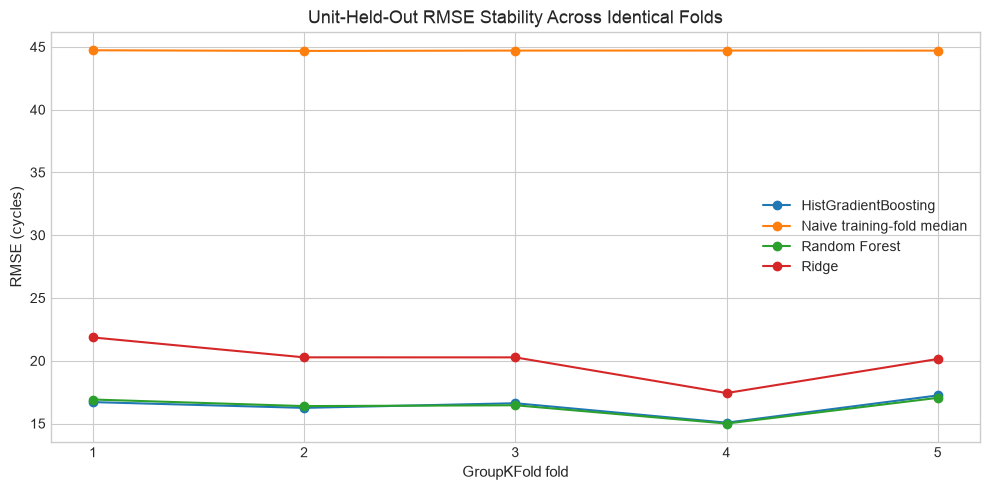

In [5]:
all_fold_results = [naive_results]
oof_predictions = {"Naive training-fold median": naive_oof}
fitted_by_model = {}

for name, estimator in models.items():
    started = time.perf_counter()
    fold_results, oof, fitted = evaluate_pipeline(name, estimator, X, proposed_predictors)
    fold_results["elapsed_seconds"] = time.perf_counter() - started
    all_fold_results.append(fold_results)
    oof_predictions[name] = oof
    fitted_by_model[name] = fitted
    print(f"Completed {name} in {fold_results['elapsed_seconds'].iloc[0]:.1f} seconds")

fold_results = pd.concat(all_fold_results, ignore_index=True)
summary = fold_results.groupby("Model").agg(
    RMSE_mean=("RMSE", "mean"), RMSE_std=("RMSE", "std"),
    MAE_mean=("MAE", "mean"), MAE_std=("MAE", "std"),
    R2_mean=("R2", "mean"), R2_std=("R2", "std"),
    NASA_score_mean=("NASA_mean_penalty", "mean"),
).sort_values("RMSE_mean")
display(summary)

fig, ax = plt.subplots(figsize=(10, 5))
for name, model_rows in fold_results.groupby("Model"):
    ax.plot(model_rows["fold"], model_rows["RMSE"], marker="o", label=name)
ax.set(title="Unit-Held-Out RMSE Stability Across Identical Folds", xlabel="GroupKFold fold", ylabel="RMSE (cycles)", xticks=range(1, 6))
ax.legend()
plt.tight_layout()
plt.show()

Fold variability is considered alongside mean performance. A small average advantage is not decisive if its fold spread is large or if near-failure behavior is materially worse.

## 6. Raw Predictors Versus Temporal Features

The strongest practical ML family by mean GroupKFold RMSE is carried into a controlled ablation. The raw-only pipeline uses the same model parameters, folds, and fold-safe imputation; only the temporal features are removed.

In [6]:
ml_model_names = list(models)
best_model_name = summary.loc[summary.index.isin(ml_model_names), "RMSE_mean"].idxmin()
best_full_pipeline = models[best_model_name]

if best_model_name == "Ridge":
    best_raw_pipeline = Pipeline([
        ("preprocess", make_preprocessor(raw_predictors, scale=True)),
        ("model", Ridge(alpha=10.0)),
    ])
elif best_model_name == "Random Forest":
    best_raw_pipeline = Pipeline([
        ("preprocess", make_preprocessor(raw_predictors)),
        ("model", clone(models[best_model_name].named_steps["model"])),
    ])
else:
    best_raw_pipeline = Pipeline([
        ("preprocess", make_preprocessor(raw_predictors)),
        ("model", clone(models[best_model_name].named_steps["model"])),
    ])

raw_fold_results, raw_oof, _ = evaluate_pipeline(
    f"{best_model_name} — raw only", best_raw_pipeline, X_raw, raw_predictors
)
full_rows = fold_results.loc[fold_results["Model"].eq(best_model_name)]
ablation = pd.DataFrame({
    "Feature set": ["Raw predictors only", "Raw + temporal predictors"],
    "Predictor count": [len(raw_predictors), len(proposed_predictors)],
    "RMSE mean": [raw_fold_results["RMSE"].mean(), full_rows["RMSE"].mean()],
    "MAE mean": [raw_fold_results["MAE"].mean(), full_rows["MAE"].mean()],
    "R2 mean": [raw_fold_results["R2"].mean(), full_rows["R2"].mean()],
})
display(ablation)
print(f"Temporal-feature RMSE change: {ablation.loc[1, 'RMSE mean'] - ablation.loc[0, 'RMSE mean']:+.3f} cycles")

,Feature set,Predictor count,RMSE mean,MAE mean,R2 mean
0,Raw predictors only,17,16.6193,11.4024,0.8407
1,Raw + temporal predictors,47,16.3588,11.1010,0.8456


Temporal-feature RMSE change: -0.260 cycles


## 7. Out-of-Fold Prediction Behavior

Every prediction below comes from a model trained without the corresponding engine unit. RUL bands are operational summaries rather than learned thresholds:

- near failure: 0–30 cycles;
- mid-life: 31–80 cycles;
- healthy/early: above 80 cycles.

,observations,RMSE,MAE,mean_error_prediction_minus_actual
rul_band,,,,
Near failure (0–30),"3,100.0000",9.7167,5.9988,3.8937
Mid-life (31–80),"5,000.0000",21.8157,17.1600,10.6425
Healthy/early (>80),"12,531.0000",15.1064,9.9452,-5.6332


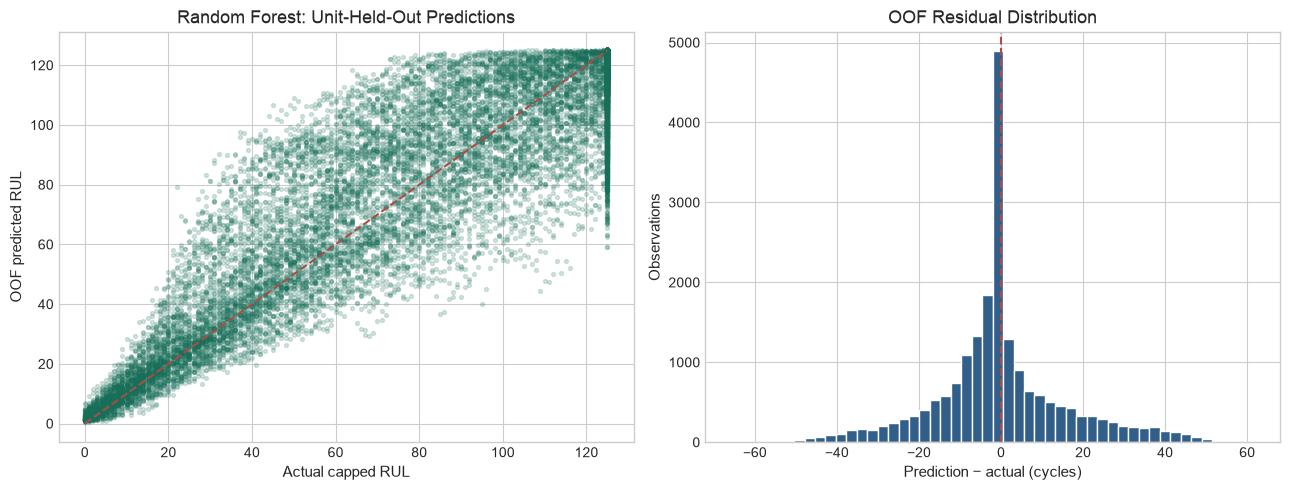

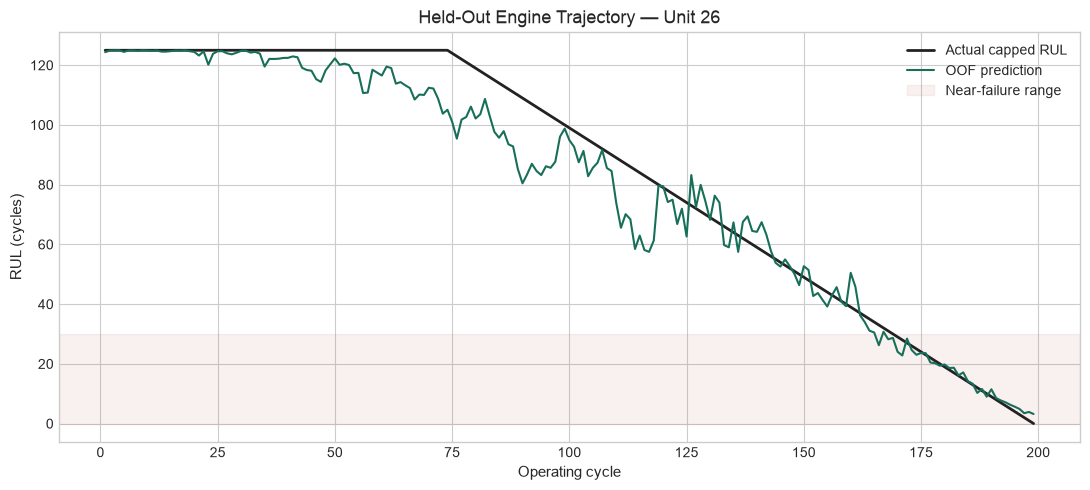

In [7]:
best_oof = oof_predictions[best_model_name]
analysis = features[["unit_id", "cycle", "capped_rul"]].copy()
analysis["oof_prediction"] = best_oof
analysis["residual"] = analysis["oof_prediction"] - analysis["capped_rul"]
analysis["rul_band"] = pd.cut(
    analysis["capped_rul"], bins=[-np.inf, 30, 80, np.inf],
    labels=["Near failure (0–30)", "Mid-life (31–80)", "Healthy/early (>80)"]
)

band_metrics = analysis.groupby("rul_band", observed=True).apply(
    lambda frame: pd.Series({
        "observations": len(frame),
        "RMSE": mean_squared_error(frame["capped_rul"], frame["oof_prediction"]) ** 0.5,
        "MAE": mean_absolute_error(frame["capped_rul"], frame["oof_prediction"]),
        "mean_error_prediction_minus_actual": frame["residual"].mean(),
    }), include_groups=False
)
display(band_metrics)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(analysis["capped_rul"], analysis["oof_prediction"], s=8, alpha=0.18, color="#176f59")
axes[0].plot([0, RUL_CAP], [0, RUL_CAP], "--", color="#ad4b45")
axes[0].set(title=f"{best_model_name}: Unit-Held-Out Predictions", xlabel="Actual capped RUL", ylabel="OOF predicted RUL")
axes[1].hist(analysis["residual"], bins=50, color="#315f8a", edgecolor="white")
axes[1].axvline(0, color="#ad4b45", linestyle="--")
axes[1].set(title="OOF Residual Distribution", xlabel="Prediction − actual (cycles)", ylabel="Observations")
plt.tight_layout()
plt.show()

lifetimes = analysis.groupby("unit_id")["cycle"].max()
representative_unit = int((lifetimes - lifetimes.median()).abs().idxmin())
unit_oof = analysis.loc[analysis["unit_id"].eq(representative_unit)]
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(unit_oof["cycle"], unit_oof["capped_rul"], label="Actual capped RUL", color="#222222", linewidth=2)
ax.plot(unit_oof["cycle"], unit_oof["oof_prediction"], label="OOF prediction", color="#176f59", linewidth=1.5)
ax.axhspan(0, 30, color="#b74b45", alpha=0.08, label="Near-failure range")
ax.set(title=f"Held-Out Engine Trajectory — Unit {representative_unit}", xlabel="Operating cycle", ylabel="RUL (cycles)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Held-Out Permutation Importance

Permutation importance is calculated on one complete held-out GroupKFold partition using the already fitted best-family fold model. It measures validation RMSE deterioration when one input is shuffled. This is more defensible than treating training impurity importance as validation evidence, but remains associative—not causal—and may divide importance among correlated raw, lag, and rolling features.

,feature,RMSE_increase_mean,RMSE_increase_std,family
0,cycle,6.8595,0.1473,cycle
29,sensor_11_rolling_mean_5,3.9916,0.0424,rolling mean
19,sensor_4_rolling_mean_5,2.0753,0.0687,rolling mean
8,sensor_9,1.6587,0.0712,raw sensor
39,sensor_15_rolling_mean_5,0.6576,0.0322,rolling mean
12,sensor_14,0.6471,0.0322,raw sensor
24,sensor_7_rolling_mean_5,0.1160,0.0329,rolling mean
25,sensor_7_rolling_std_5,0.1068,0.0312,rolling std
44,sensor_21_rolling_mean_5,0.0566,0.0065,rolling mean
34,sensor_12_rolling_mean_5,0.0380,0.0132,rolling mean


,RMSE_increase_mean
family,
rolling mean,6.9351
cycle,6.8595
raw sensor,2.1434
rolling std,0.0556
operating setting,0.0016
delta,-0.0114
lag,-0.0519


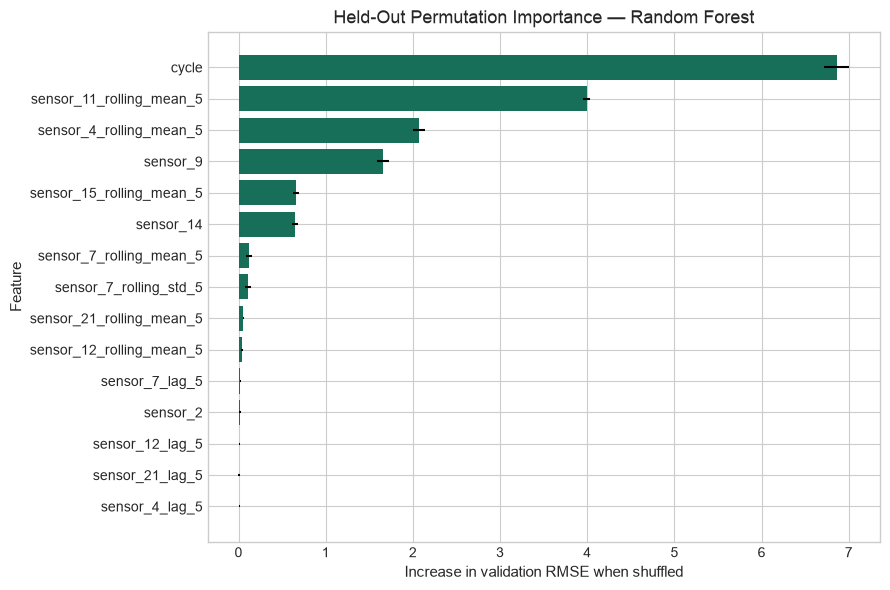

In [8]:
best_fold_estimator, importance_train_idx, importance_valid_idx = fitted_by_model[best_model_name][0]
assert not set(groups.iloc[importance_train_idx]).intersection(set(groups.iloc[importance_valid_idx]))

importance_result = permutation_importance(
    best_fold_estimator,
    X.iloc[importance_valid_idx], y.iloc[importance_valid_idx],
    scoring="neg_root_mean_squared_error", n_repeats=3, random_state=42, n_jobs=1,
)
importance = pd.DataFrame({
    "feature": proposed_predictors,
    "RMSE_increase_mean": importance_result.importances_mean,
    "RMSE_increase_std": importance_result.importances_std,
}).sort_values("RMSE_increase_mean", ascending=False)

def feature_family(name):
    if name == "cycle": return "cycle"
    if name.startswith("operational_"): return "operating setting"
    if "_rolling_mean_" in name: return "rolling mean"
    if "_rolling_std_" in name: return "rolling std"
    if "_delta_" in name: return "delta"
    if "_lag_" in name: return "lag"
    return "raw sensor"
importance["family"] = importance["feature"].map(feature_family)
display(importance.head(15))
display(importance.groupby("family")["RMSE_increase_mean"].sum().sort_values(ascending=False).to_frame())

plot_importance = importance.head(15).sort_values("RMSE_increase_mean")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_importance["feature"], plot_importance["RMSE_increase_mean"], xerr=plot_importance["RMSE_increase_std"], color="#176f59")
ax.set(title=f"Held-Out Permutation Importance — {best_model_name}", xlabel="Increase in validation RMSE when shuffled", ylabel="Feature")
plt.tight_layout()
plt.show()

## 9. Provisional Model Selection

Selection balances unit-held-out RMSE and MAE, fold stability, near-failure behavior, interpretability, and practical training cost. The selected family remains provisional because:

- the 125-cycle target cap has not been optimized or stress-tested;
- baseline hyperparameters were not tuned;
- validation includes simulated FD001 units only;
- the official endpoint test evaluation remains untouched;
- performance on real fleets may differ materially.

In [9]:
best_metrics = summary.loc[best_model_name]
near_failure = band_metrics.loc["Near failure (0–30)"]
selection_summary = pd.Series({
    "provisional_model_family": best_model_name,
    "GroupKFold_RMSE_mean": best_metrics["RMSE_mean"],
    "GroupKFold_RMSE_std": best_metrics["RMSE_std"],
    "GroupKFold_MAE_mean": best_metrics["MAE_mean"],
    "GroupKFold_R2_mean": best_metrics["R2_mean"],
    "near_failure_RMSE": near_failure["RMSE"],
    "near_failure_MAE": near_failure["MAE"],
    "temporal_feature_RMSE_change": ablation.loc[1, "RMSE mean"] - ablation.loc[0, "RMSE mean"],
})
display(selection_summary.to_frame("result"))

,result
provisional_model_family,Random Forest
GroupKFold_RMSE_mean,16.3588
GroupKFold_RMSE_std,0.8122
GroupKFold_MAE_mean,11.1010
GroupKFold_R2_mean,0.8456
near_failure_RMSE,9.7167
near_failure_MAE,5.9988
temporal_feature_RMSE_change,-0.2605


## 10. Validation Guardrails

In [10]:
# OOF coverage and unit isolation
assert all(np.isfinite(predictions).all() for predictions in oof_predictions.values())
assert all(row["unit_overlap"] == 0 for row in fold_audit.to_dict("records"))

# Feature and target isolation
assert X.shape[1] == 47
assert "unit_id" not in X.columns
assert not set(target_columns).intersection(X.columns)
assert not set(constant_sensors + near_constant_excluded).intersection(X.columns)

# Methodology controls
preprocessing_is_inside_each_pipeline = all("preprocess" in estimator.named_steps for estimator in models.values())
official_test_rul_labels_loaded = False
production_artifact_created = False
random_row_level_split_used = False
assert preprocessing_is_inside_each_pipeline
assert not official_test_rul_labels_loaded
assert not production_artifact_created
assert not random_row_level_split_used

validation = pd.Series({
    "all_code_uses_47_predictors": X.shape[1] == 47,
    "no_unit_overlap_in_any_fold": bool((fold_audit["unit_overlap"] == 0).all()),
    "preprocessing_inside_model_pipelines": preprocessing_is_inside_each_pipeline,
    "targets_absent_from_predictors": not set(target_columns).intersection(X.columns),
    "all_ML_OOF_predictions_complete": all(np.isfinite(oof_predictions[name]).all() for name in models),
    "official_test_labels_used": official_test_rul_labels_loaded,
    "production_artifact_created": production_artifact_created,
    "random_row_split_used": random_row_level_split_used,
})
display(validation.to_frame("result"))

,result
all_code_uses_47_predictors,True
no_unit_overlap_in_any_fold,True
preprocessing_inside_model_pipelines,True
targets_absent_from_predictors,True
all_ML_OOF_predictions_complete,True
official_test_labels_used,False
production_artifact_created,False
random_row_split_used,False


## RUL Modeling Conclusions

- **Naive median baseline:** RMSE 44.70, MAE 35.75, and R² -0.151. All ML candidates improve substantially over this leakage-safe constant prediction.
- **Ridge:** RMSE 19.99 ± 1.60, MAE 16.26 ± 1.31, and R² 0.769 ± 0.036. Linear structure is useful but does not fully represent nonlinear degradation.
- **Random Forest:** RMSE 16.36 ± 0.81, MAE 11.10 ± 0.66, R² 0.846 ± 0.015, and mean NASA penalty 5.94.
- **Histogram Gradient Boosting:** RMSE 16.37 ± 0.81, MAE 11.09 ± 0.63, R² 0.845 ± 0.015, and mean NASA penalty 6.25. It trained roughly five times faster in this baseline run.
- Random Forest and Histogram Gradient Boosting are statistically tied at this resolution: their mean RMSE differs by only 0.015 cycles and their fold variability is effectively identical. Random Forest is selected **provisionally**, not from the tiny RMSE edge alone, but because it also achieved the lower domain-specific NASA penalty and supported direct held-out interpretation. Boosting remains a credible efficiency-oriented alternative.
- Adding 30 temporal predictors to Random Forest improved mean RMSE from 16.62 to 16.36, MAE from 11.40 to 11.10, and R² from 0.841 to 0.846. The gain is real under identical unit-held-out folds but modest, so feature complexity should be reassessed during later tuning.
- Near failure, OOF RMSE was 9.72 and MAE was 6.00. Mean error was +3.89 cycles, indicating a small but operationally important tendency to overestimate remaining life. Mid-life was hardest (RMSE 21.82; MAE 17.16), while healthy/early observations reached RMSE 15.11.
- Held-out permutation importance was led by cycle, rolling means for sensors 11 and 4, raw sensor 9, the sensor 15 rolling mean, and raw sensor 14. Correlated features can share or suppress importance, and these rankings are predictive associations rather than physical causality.
- All results use identical five-fold GroupKFold partitions with 80 training units, 20 validation units, zero unit overlap, and fold-local preprocessing.
- The capped target simplifies early-life prediction but suppresses distinctions above 125 cycles and is not yet proven optimal.
- FD001 is simulated, single-condition data. Real-world deployment requires external fleet validation, drift monitoring, and operational cost analysis.

**Recommended next step:** create `notebooks/09_rul_test_evaluation.ipynb` to freeze the selected methodology, refit using training data, and evaluate only final test-unit endpoints against the previously untouched official RUL labels. Notebook 09 is not created here.